# Lizbeth's Final Project - Machine Learning
## **Introduction**

For my final project, I decided to use the **Online Shoppers Purchasing Intention Dataset** from UCI's Machine Learning Repository.  The dataset shows customer behaivor during online shopping sessions including visit timing, whether the visitor is new or returning, and how long each session lasts.  Each session is labeled as true or false depending if there was a purchase made.

In this project, I will focus on the following questions:
- Which session features influence whether a purchase is made?
- What user behaviors are most associated with completed transactions?
- Can a machine learning model accurately predict whether an online session will result in a purchase?






In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [2]:
# Importing the Data

df = pd.read_csv('online_shoppers_intention[1].csv')
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


Sakar, C. & Kastro, Y. (2018). Online Shoppers Purchasing Intention Dataset [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5F88Q.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [4]:
df.duplicated().sum()
# Won't be dropping dupes because each row represents a seperate session.

np.int64(125)

In [ ]:
# Profile Report

# Install the library
!pip install -q ydata-profiling

# Import after installation
from ydata_profiling import ProfileReport

# Create and save profiling report
profile = ProfileReport(
df,
title="Online Shopper Intentions Report",
explorative=True
)

# Save to /content so it appears in Files
profile.to_file("/content/profiling_report.html")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.4 MB/s eta 0:00:00


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 18/18 [00:00<00:00, 55.42it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

A profiling report was generated to provide an overview of the dataset. The report confirmed that there are no missing values in the data.

## **Exploratory Data Analysis**

The Online Shoppers Purchasing Intention dataset contains over **12,000** online shopping sessions with a mix of **numerical and categorical** features. The dataset includes information such as page visits, time spent on pages, visitor type, bounce rates, and page values. The target variable, Revenue, indicates whether a session resulted in a purchase. There are no missing values in the dataset.


/tmp/ipython-input-1271408999.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'Revenue', data = df, palette = ['#f4a6b8', '#ff69b4'])


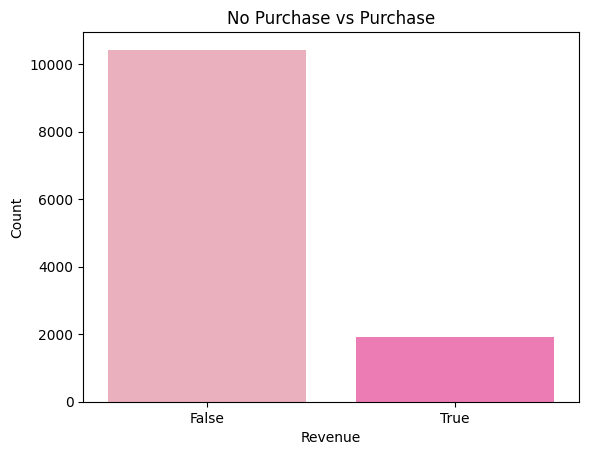

In [5]:
# Checking for Imbalance
sns.countplot(x = 'Revenue', data = df, palette = ['#f4a6b8', '#ff69b4'])
plt.title('No Purchase vs Purchase')
plt.xlabel('Revenue')
plt.ylabel('Count')
plt.show()

There is a class imbalance in this dataset, most sessions did not end with a complete transaction.

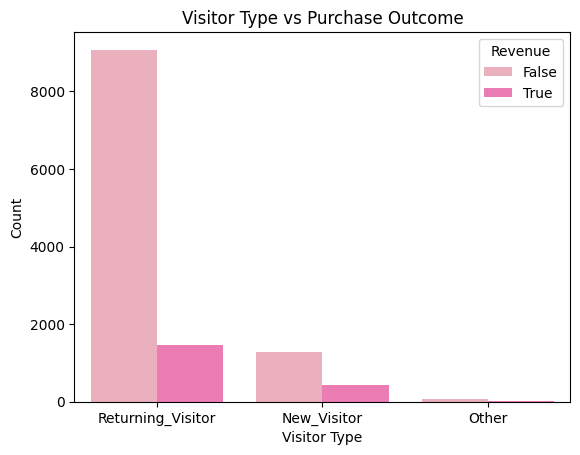

In [6]:
# New Customer vs Returning Customer Behaivor
sns.countplot(x = 'VisitorType', data = df, palette = ['#f4a6b8', '#ff69b4'], hue='Revenue')
plt.title('Visitor Type vs Purchase Outcome')
plt.xlabel('Visitor Type')
plt.ylabel('Count')
plt.show()


Based on the plot above, returning customers are more likely to complete a transaction compared to new/other visitors.

# **Preprocessing**
Before building the machine learning models, preprocessing steps will be applied to prepare the data for analysis.  These following steps will ensure features are properly formatted and scaled for the modeling.

In [7]:
# Categorical and Numerical Features

categorical_features = [
    'Month',
    'VisitorType',
    'Weekend'
]

numerical_features = [
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues',
    'SpecialDay'
]

In [18]:
# Encoding Catergorical Variables
df_encoded = pd.get_dummies(
    df,
    columns = categorical_features,
    drop_first = True
)

In [19]:
# Target Variable
y = df_encoded['Revenue']

# Features
X = df_encoded.drop('Revenue', axis = 1)

In [22]:
# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y # ensures percentages stay the same in test-train split
)

In [24]:
# Scaling Features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.shape

(9864, 26)

After the preprocessing steps, the training data consists of 9,864 sessions with 26 features.

#**Model Implementation**

For the model implementation, **logistic regression** was selected because the problem is a binary classification task.  The model provides a strong baseline for predicting whether visitors would complete an online shopping transaction.

In [25]:
from sklearn.linear_model import LogisticRegression

# Training the Model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [26]:
# Predictions
y_pred = model.predict(X_test_scaled)

#**Model Evaluation**

Since logistic regression was used for this classification task, the model was evaluated using a confusion matrix along with accuracy and F1 score to better assess its performance.

In [66]:
# I asked ChatGPT how to match
# confusion matrix colors to previous plots

from matplotlib.colors import LinearSegmentedColormap

# Custom pink colormap
pink_cmap = LinearSegmentedColormap.from_list(
    "liz_pink",
    ['#ffc0cb', '#e37383', '#ffb6c1', '#f3cfc6']
)


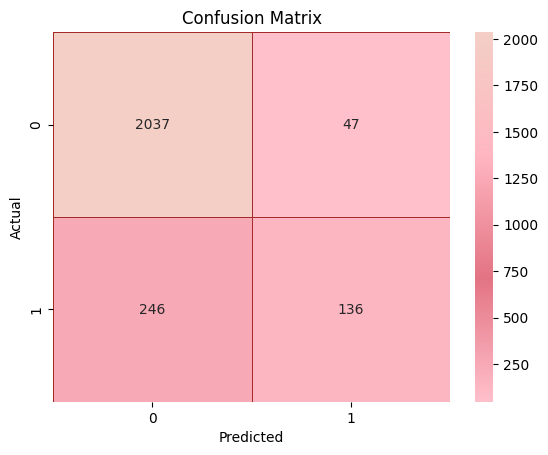

In [67]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Display CM
sns.heatmap(
    cm,
    annot = True,
    fmt = 'd',
    cmap = pink_cmap,
    linewidths = 0.5,
    linecolor = 'brown',
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Based on the confusion matrix, the logistic regression model performed well at identifying sessions that did not result in a purchase, which can be due to the class imbalance.  The model did struggle to correctly identify all of the sessions that did end in a purchase as reflected by the high number of false negatives.

In [65]:
# Metrics

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.89      0.98      0.93      2084
        True       0.74      0.36      0.48       382

    accuracy                           0.88      2466
   macro avg       0.82      0.67      0.71      2466
weighted avg       0.87      0.88      0.86      2466



The model achieved an accuracy of **88%** but showed lower recall for purchasing sessions, indicating difficulty identifying all purchases due to class imbalance.

#**Conclusion**

This final project used logistic regression to predict whether an online shopping session would end with a purchase using the **Online Shoppers Purchasing Intention** dataset from UCI's Machine Learning Repository.  Exploratory analysis showed that features like visitor type did influence purchasing behavior, with returning customers being more likely to make a purchase.  
The logistic model achieved an accuracy score of **88%**, indicating that it was effective at identifying patterns in online shopping behaviors.  But there was a lower recall score for the purchasing sessions due to the class imbalance within the dataset.  
Overall, this project demonstrates how machine learning can be used to better understand online customer behavior while also highlighting opportunities for improving model performance.